# From 10 minutes to 4 seconds
## Solving large systems with Jacobi + GMRES

**Romain Sacchi (PSI) · Brightcon 2026 · 25 September 2026 · 8 minutes**<br> Direct solvers are a good default. But their factors can contain many more nonzeros than the original matrix. This extra storage is called **fill-in**. Jacobi + GMRES can avoid it when convergence is fast enough.


# How it started

![UMFPACK vs. JacobiGMRED](assets/figure_1.png)

## Goals

1. See how matrix size, density, and structure affect solve time and memory.
2. Compare direct solvers with Jacobi + GMRES.
3. Reuse a factorization for many demands on one matrix.
4. Solve 500 changing matrices, with and without a previous solution as a starting guess.

Run this notebook from the repository folder. The main comparisons use synthetic data.
The final optional examples use an existing local Brightway project.
The larger grids can take several minutes.


In [1]:
from dev.benchmark_synthetic import banded_matrix, constant_degree_matrix, solve
from dev.run_synthetic_suite import run_benchmark
from scipy.sparse.linalg import LinearOperator, gmres

/opt/homebrew/Caskroom/miniforge/base/envs/premise/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
import importlib.metadata
import sys
from time import perf_counter

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import psutil
import scipy
from IPython.display import Markdown, display

SEED = 2026
RTOL = 1e-4
available_mib = psutil.virtual_memory().available / 2**20
memory_guard_mib = int(min(8_192, available_mib * 0.25))
try:
    import pypardiso

    PARDISO_AVAILABLE = True
except ImportError:
    PARDISO_AVAILABLE = False
DIRECT_SOLVERS = ["umfpack"] + (["pardiso"] if PARDISO_AVAILABLE else [])
colors = {
    "numpy-dense": "#7F8C8D",
    "superlu": "#C44E52",
    "umfpack": "#DD8452",
    "pardiso": "#937860",
    "gmres": "#4C72B0",
    "jacobi-gmres": "#12A594",
    "jacobi-gmres-no-guess": "#8172B2",
}
solver_names = {
    "numpy-dense": "NumPy dense",
    "superlu": "SuperLU",
    "umfpack": "UMFPACK",
    "pardiso": "Pardiso",
    "gmres": "GMRES",
    "jacobi-gmres": "Jacobi + GMRES",
    "jacobi-gmres-no-guess": "Jacobi + GMRES (no warm start)",
}


def observed_log_ratio_scale(values):
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    limit = max(float(np.max(np.abs(finite))), 0.25) if finite.size else 1.0
    ticks = np.linspace(-limit, limit, 5)
    labels = [
        f"{10 ** tick:,.0f}×" if 10**tick >= 1 else f"{10 ** tick:.2g}×"
        for tick in ticks
    ]
    return limit, ticks, labels


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "figure.dpi": 120,
    }
)


solver_order = ["numpy-dense", "superlu", *DIRECT_SOLVERS, "gmres", "jacobi-gmres"]

{
    "benchmark mode": "live synthetic benchmarks",
    "worker Python": sys.executable,
    "NumPy": np.__version__,
    "SciPy": scipy.__version__,
    "scikit-umfpack": importlib.metadata.version("scikit-umfpack"),
}


{'benchmark mode': 'live synthetic benchmarks',
 'worker Python': '/opt/homebrew/Caskroom/miniforge/base/envs/premise/bin/python',
 'NumPy': '1.24.4',
 'SciPy': '1.15.2',
 'scikit-umfpack': '0.3.3'}

## Solver toolbox

- **NumPy dense** stores all entries, including zeros. It is useful as a small reference case.
- **SuperLU**, **UMFPACK**, and optional **Pardiso** factor a sparse matrix, then solve using those factors.
- **GMRES** improves an approximate solution through repeated matrix-vector products.
- **Jacobi + GMRES** uses the inverse diagonal to rescale the equations before iterating.

We use `rtol=1e-4`, `restart=50`, and `maxiter=300`.
Check both the GMRES return code (`info == 0`) and the relative residual
$\|Ax-b\|/\|b\|$.  
Note that a small residual alone does not guarantee a small error in the solution.


### Jacobi + GMRES: try one solve

For $Ax=b$, Jacobi applies $D^{-1}$, where $D$ is the diagonal of $A$.  
A `LinearOperator` applies this scaling without creating a dense matrix.  
The callback counts inner GMRES steps. `maxiter` limits restart cycles.  
Compare the solution with a direct solve as well as checking the residual.


In [3]:
A = constant_degree_matrix(500, degree=8, seed=SEED, diagonal_span=4.0)
b = np.zeros(A.shape[0])
b[0] = 1.0
inverse_diagonal = 1.0 / A.diagonal()
M = LinearOperator(A.shape, matvec=lambda vector: inverse_diagonal * vector)
residual_history = []
x, info = gmres(
    A,
    b,
    M=M,
    rtol=RTOL,
    atol=0.0,
    restart=50,
    maxiter=300,
    callback=residual_history.append,
    callback_type="pr_norm",
)
reference, _, _ = solve(A, b, "superlu", RTOL, 50, 300)
relative_residual = np.linalg.norm(A @ x - b) / np.linalg.norm(b)
relative_difference = np.linalg.norm(x - reference) / np.linalg.norm(reference)
assert info == 0 and relative_residual <= RTOL * 1.01
print(f"{len(residual_history)} GMRES steps")
print(f"Relative residual: {relative_residual:.2e}")
print(f"Relative solution difference: {relative_difference:.2e}")


6 GMRES steps
Relative residual: 4.45e-05
Relative solution difference: 1.16e-06


# 1 · Matrix size and solve cost

Start with roughly eight inputs per activity, from 500 to 50,000 activities.  
Each solver runs in a separate process so previous allocations do not affect its memory measurement.  
The helper samples resident memory (RSS) every 2 ms; very short peaks may be missed.  
Additional memory is measured from the point just before solving.  

The process runner is ordinary Python in `dev/run_synthetic_suite.py`.

In [4]:
synthetic_payload = run_benchmark(
    "scaling",
    sizes=[500, 1_000, 5_000, 10_000, 20_000],
    solvers=["numpy-dense", "jacobi-gmres", *DIRECT_SOLVERS, "gmres", "superlu"],
    rtol=RTOL,
    worker_timeout=12, # we limit each case to 12 sec, otherwise we skip it
    total_budget=65, # we limit the entire benchmark to 65 sec
)
synthetic = pd.json_normalize(synthetic_payload["results"])
synthetic["memory_mib"] = synthetic["incremental_peak_rss_bytes"] / 2**20


scaling: 19 COMPLETED, 3 SKIPPED, 2 TIMEOUT, 1 FAILED


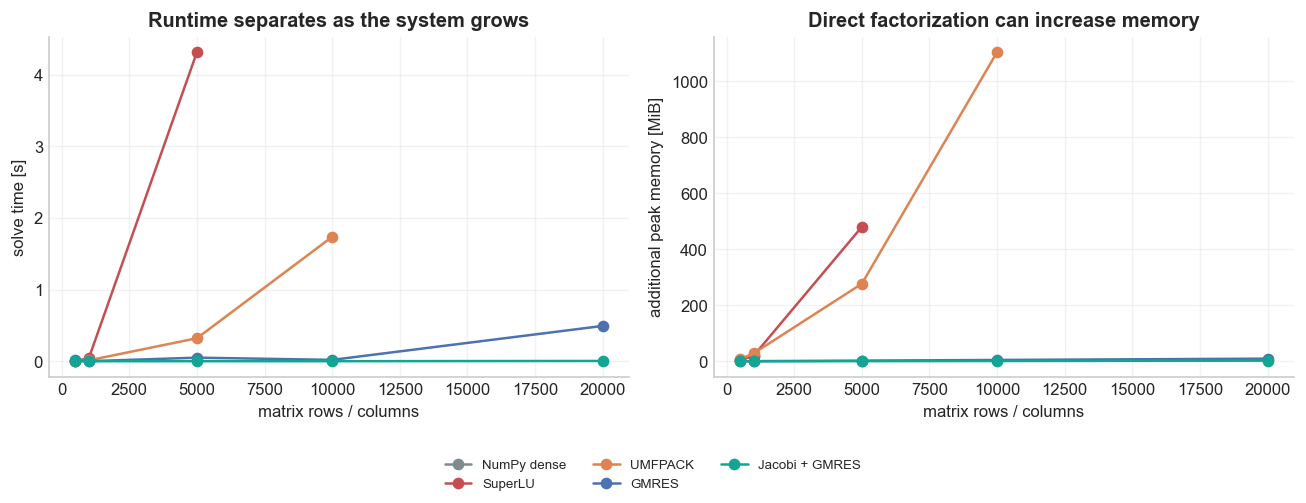

solver,size,status
numpy-dense,5000,SKIPPED
numpy-dense,10000,SKIPPED
superlu,10000,TIMEOUT
numpy-dense,20000,SKIPPED
umfpack,20000,OUT OF MEMORY
superlu,20000,TIMEOUT


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
valid = synthetic[synthetic["status"] == "COMPLETED"]
for solver in solver_order:
    subset = valid[valid.solver == solver].sort_values("size")
    if subset.empty:
        continue
    label = solver_names[solver]
    axes[0].plot(
        subset["size"], subset["solve_seconds"], "o-", label=label, color=colors[solver]
    )
    axes[1].plot(
        subset["size"], subset["memory_mib"], "o-", label=label, color=colors[solver]
    )

axes[0].set_ylabel("solve time [s]")
axes[1].set_ylabel("additional peak memory [MiB]")
for axis in axes:
    axis.set_xlabel("matrix rows / columns")
    axis.grid(alpha=0.25, which="both")
axes[0].set_title("Runtime separates as the system grows")
axes[1].set_title("Direct factorization can increase memory")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, fontsize=8)
fig.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

not_completed_scaling = synthetic[synthetic.status != "COMPLETED"].copy()
if not not_completed_scaling.empty:
    oom = (
        not_completed_scaling["error"]
        .fillna("")
        .str.contains("out_of_memory", case=False)
    )
    not_completed_scaling.loc[oom, "status"] = "OUT OF MEMORY"
    display(
        not_completed_scaling[["solver", "size", "status"]].style.hide(axis="index")
    )


### Density versus size

**Matrix density** is the share of matrix entries that are nonzero.  
This sweep varies both system size and density from 0.1% (e.g., ecoinvent) to 5% (e.g., EXIOBASE). 
The later stress test covers 3% to 15% and shows which combinations exceed the memory limit.

Each heatmap cell answers one question:
**how many times faster is one solver than the other?**


In [6]:
%%time

density_size_payload = run_benchmark(
    "density versus size",
    sizes=[1_000, 5_000, 7_500],
    solvers=["jacobi-gmres", *DIRECT_SOLVERS],
    topology="fixed-density",
    densities=[0.01, 0.03, 0.05],
    rtol=RTOL,
    worker_timeout=12,
    total_budget=45,
    memory_guard_mib=memory_guard_mib,
)
density_size = pd.json_normalize(density_size_payload["results"])
density_size["speedup"] = np.nan
for (size, density), subset in density_size[density_size.status == "COMPLETED"].groupby(
    ["size", "target_density"]
):
    direct = subset.loc[subset.solver == "umfpack", "solve_seconds"]
    iterative = subset.loc[subset.solver == "jacobi-gmres", "solve_seconds"]
    if len(direct) == len(iterative) == 1:
        density_size.loc[subset.index, "speedup"] = direct.iloc[0] / iterative.iloc[0]

heat = density_size[density_size.solver == "jacobi-gmres"].pivot(
    index="target_density", columns="size", values="speedup"
)
log_heat = np.log10(heat)
heat_limit, heat_ticks, heat_tick_labels = observed_log_ratio_scale(log_heat)


density versus size: 18 COMPLETED, 0 SKIPPED, 0 TIMEOUT, 0 FAILED
CPU times: user 9.62 ms, sys: 44.6 ms, total: 54.3 ms
Wall time: 11.9 s


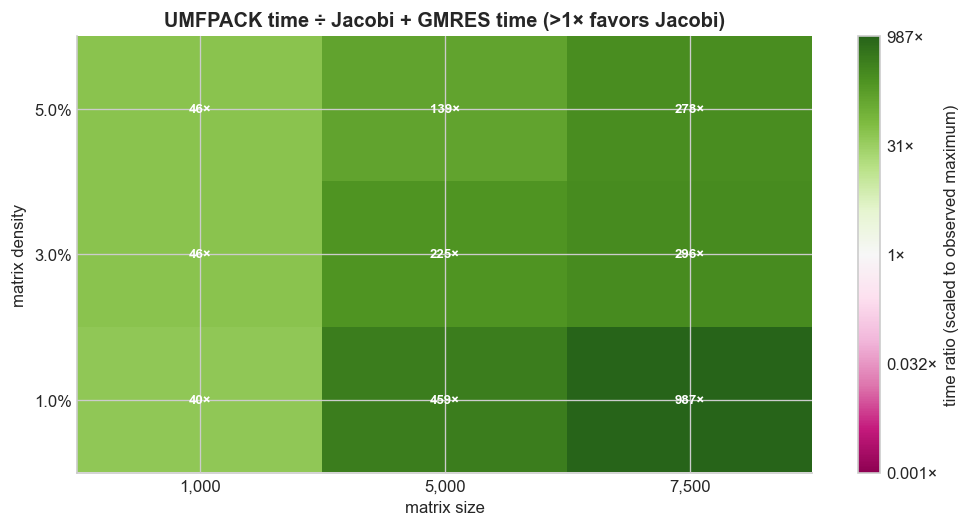

In [7]:
fig, axis = plt.subplots(figsize=(8.5, 4.5))
image = axis.imshow(
    log_heat,
    aspect="auto",
    origin="lower",
    cmap="PiYG",
    vmin=-heat_limit,
    vmax=heat_limit,
)
axis.set_xticks(range(len(heat.columns)), [f"{n:,}" for n in heat.columns])
axis.set_yticks(range(len(heat.index)), [f"{density:.1%}" for density in heat.index])
axis.set_xlabel("matrix size")
axis.set_ylabel("matrix density")
axis.set_title("UMFPACK time ÷ Jacobi + GMRES time (>1× favors Jacobi)")
for row, density in enumerate(heat.index):
    for column, size in enumerate(heat.columns):
        value = heat.loc[density, size]
        if np.isfinite(value):
            label = f"{value:.0f}×" if value >= 1 else "<1×"
            text_color = (
                "white" if abs(np.log10(value)) > 0.45 * heat_limit else "black"
            )
            axis.text(
                column,
                row,
                label,
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
                fontweight="bold",
            )
bar = fig.colorbar(image, ax=axis, label="time ratio (scaled to observed maximum)")
bar.set_ticks(heat_ticks)
bar.set_ticklabels(heat_tick_labels)
fig.tight_layout()
plt.show()


### Large synthetic systems

Here we measure **Jacobi + GMRES only** at 10,000, 20,000, 30,000, 60,000, 100,000, and 300,000 rows.
The earlier comparisons already show the cost of direct solving.
The left plot shows solve time at **1% density**; the right shows peak memory at
**0.5%, 1%, 5%, and 10% density**.

Each sweep has a **60-second budget**, with at most **30 seconds per case**.
Cases that exceed the construction-memory estimate or remaining time budget are skipped.
A slower server may show fewer completed points.

The intermediate sizes give the curves more points without raising the memory limit.
More time cannot make a case fit in memory; the largest cases may still be skipped.


In [8]:
%%time

large_sizes = [10_000, 20_000, 30_000, 60_000]
large_memory_guard_mib = min(4_096, memory_guard_mib)
large_jacobi_scale_payload = run_benchmark(
    "large Jacobi systems at 1 percent",
    sizes=large_sizes,
    solvers=["jacobi-gmres"],
    topology="fixed-density",
    densities=[0.01],
    rtol=RTOL,
    worker_timeout=30,
    total_budget=60,
    memory_guard_mib=large_memory_guard_mib,
    construction_memory_multiplier=3.0,
)
large_memory_payload = run_benchmark(
    "large systems memory by density",
    sizes=large_sizes,
    solvers=["jacobi-gmres"],
    topology="fixed-density",
    densities=[0.005, 0.05, 0.1],
    rtol=RTOL,
    worker_timeout=30,
    total_budget=60,
    memory_guard_mib=large_memory_guard_mib,
    construction_memory_multiplier=3.0,
)
large_jacobi_scale = pd.json_normalize(large_jacobi_scale_payload["results"])
large_memory = pd.json_normalize(large_memory_payload["results"])
completed_scale = large_jacobi_scale[large_jacobi_scale.status == "COMPLETED"].copy()
completed_memory = large_memory[large_memory.status == "COMPLETED"].copy()
memory_plot = pd.concat(
    [
        completed_memory,
        completed_scale[
            (completed_scale["solver"] == "jacobi-gmres")
            & np.isclose(completed_scale["target_density"], 0.01)
        ],
    ],
    ignore_index=True,
).drop_duplicates(["size", "target_density"], keep="last")
memory_plot["peak_rss_mib"] = memory_plot["peak_rss_bytes"] / 2**20
size_position = {size: index for index, size in enumerate(large_sizes)}
density_colors = {0.005: "#4C72B0", 0.01: "#55A868", 0.05: "#C44E52", 0.1: "#8172B2"}


large Jacobi systems at 1 percent: 4 COMPLETED, 2 SKIPPED, 0 TIMEOUT, 0 FAILED
large systems memory by density: 8 COMPLETED, 10 SKIPPED, 0 TIMEOUT, 0 FAILED
CPU times: user 6.76 ms, sys: 33.8 ms, total: 40.5 ms
Wall time: 17.3 s


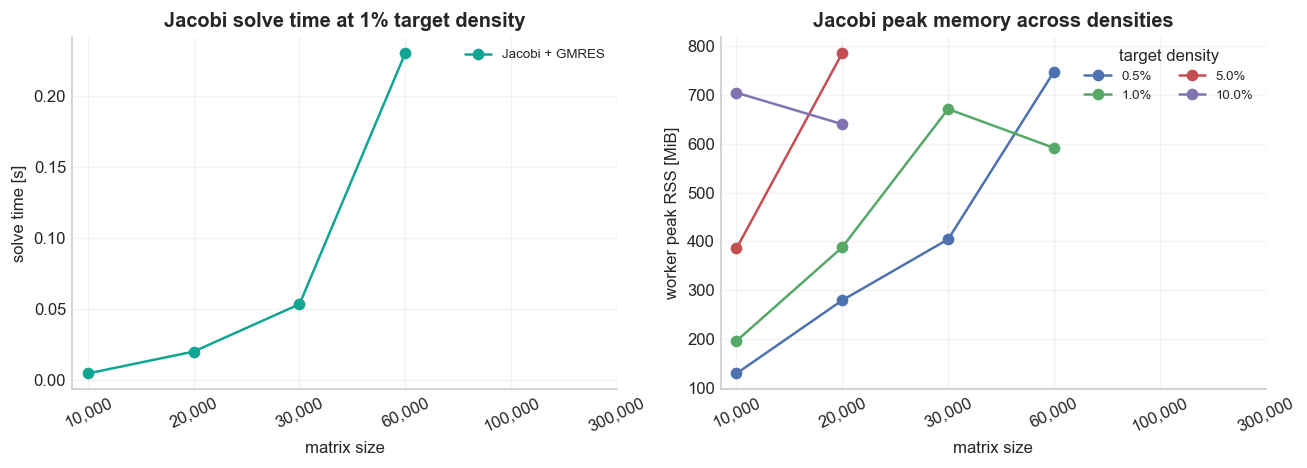

suite,size,target_density,skip_reason
1% Jacobi comparison,100000,0.010000,MEMORY GUARD
1% Jacobi comparison,300000,0.010000,MEMORY GUARD
Jacobi density sweep,30000,0.050000,MEMORY GUARD
Jacobi density sweep,30000,0.100000,MEMORY GUARD
Jacobi density sweep,60000,0.050000,MEMORY GUARD
Jacobi density sweep,60000,0.100000,MEMORY GUARD
Jacobi density sweep,100000,0.005000,MEMORY GUARD
Jacobi density sweep,100000,0.050000,MEMORY GUARD
Jacobi density sweep,100000,0.100000,MEMORY GUARD
Jacobi density sweep,300000,0.005000,MEMORY GUARD


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for solver, subset in completed_scale.groupby("solver"):
    subset = subset.sort_values("size")
    label = solver_names[solver]
    axes[0].plot(
        [size_position[size] for size in subset["size"]],
        subset["solve_seconds"],
        "o-",
        label=label,
        color=colors[solver],
    )
for density, subset in memory_plot.groupby("target_density"):
    subset = subset.sort_values("size")
    axes[1].plot(
        [size_position[size] for size in subset["size"]],
        subset["peak_rss_mib"],
        "o-",
        label=f"{density:.1%}",
        color=density_colors[density],
    )
for axis in axes:
    axis.set_xlabel("matrix size")
    axis.grid(alpha=0.25)
    axis.set_xticks(
        range(len(large_sizes)), [f"{size:,}" for size in large_sizes], rotation=25
    )
axes[0].set_ylabel("solve time [s]")
axes[1].set_ylabel("worker peak RSS [MiB]")
axes[0].set_title("Jacobi solve time at 1% target density")
axes[1].set_title("Jacobi peak memory across densities")
axes[0].legend(frameon=False, fontsize=8)
axes[1].legend(frameon=False, fontsize=8, ncol=2, title="target density")
fig.tight_layout()
plt.show()

large_status = pd.concat(
    [
        large_jacobi_scale.assign(suite="1% Jacobi comparison"),
        large_memory.assign(suite="Jacobi density sweep"),
    ],
    ignore_index=True,
)
not_completed = large_status[large_status.status != "COMPLETED"].copy()
if not not_completed.empty:
    error_text = (
        not_completed["error"].fillna("")
        if "error" in not_completed
        else pd.Series("", index=not_completed.index)
    )
    oom = error_text.str.contains("out_of_memory", case=False)
    not_completed.loc[oom, "status"] = "OUT OF MEMORY"
    failed = not_completed[not_completed["status"] != "SKIPPED"]
    if not failed.empty:
        display(
            failed[["suite", "solver", "size", "target_density", "status"]].style.hide(
                axis="index"
            )
        )
    skipped = not_completed[not_completed["status"] == "SKIPPED"]
    if not skipped.empty:
        display(
            skipped[["suite", "size", "target_density", "skip_reason"]].style.hide(
                axis="index"
            )
        )


### A large matrix where direct solving works well

A banded matrix connects nearby activities. Its factors have little fill-in, so a direct solver can be fast even for a large system.
Compare `lu_fill_ratio` (nonzeros in the factors divided by nonzeros in the matrix), solve time, and residual.


In [10]:
banded_payload = run_benchmark(
    "low-fill counterexample",
    sizes=[50_000],
    solvers=["superlu", *DIRECT_SOLVERS, "jacobi-gmres"],
    topology="banded",
    degree=4,
    rtol=RTOL,
    worker_timeout=15,
    total_budget=45,
)
banded = pd.json_normalize(banded_payload["results"])
display(
    banded.reindex(
        columns=[
            "solver",
            "size",
            "nnz",
            "status",
            "solve_seconds",
            "lu_fill_ratio",
            "relative_residual",
        ]
    )
)


low-fill counterexample: 3 COMPLETED, 0 SKIPPED, 0 TIMEOUT, 0 FAILED


,solver,size,nnz,status,solve_seconds,lu_fill_ratio,relative_residual
0,superlu,50000,449980,COMPLETED,0.019843,1.412189,8.417861e-15
1,umfpack,50000,449980,COMPLETED,0.021288,1.111116,5.270149e-15
2,jacobi-gmres,50000,449980,COMPLETED,0.016497,NaN,5.917275e-05


# 2 · Fixed matrix, many right-hand sides

One fixed 40,000 × 40,000 matrix can serve many demands.  
The left plot separates the one-time factorization from the first solve.  
The right plot then shows total time as more demands reuse that same matrix.


In [11]:
%%time

rhs_payload = run_benchmark(
    "fixed matrix demands",
    sizes=[40_000],
    solvers=[*DIRECT_SOLVERS, "jacobi-gmres"],
    topology="banded",
    degree=30,
    rhs_counts=[1, 3, 10, 25, 50, 100],
    rtol=RTOL,
    worker_timeout=15,
    total_budget=50,
)
rhs_all = pd.json_normalize(rhs_payload["results"])
display(rhs_all[["solver", "rhs_count", "status", "skip_reason"]])
rhs = rhs_all[rhs_all.status == "COMPLETED"]


fixed matrix demands: 12 COMPLETED, 0 SKIPPED, 0 TIMEOUT, 0 FAILED


,solver,rhs_count,status,skip_reason
0,umfpack,1,COMPLETED,
1,jacobi-gmres,1,COMPLETED,
2,umfpack,3,COMPLETED,
3,jacobi-gmres,3,COMPLETED,
4,umfpack,10,COMPLETED,
5,jacobi-gmres,10,COMPLETED,
6,umfpack,25,COMPLETED,
7,jacobi-gmres,25,COMPLETED,
8,umfpack,50,COMPLETED,
9,jacobi-gmres,50,COMPLETED,


CPU times: user 5.96 ms, sys: 22.7 ms, total: 28.7 ms
Wall time: 9.11 s


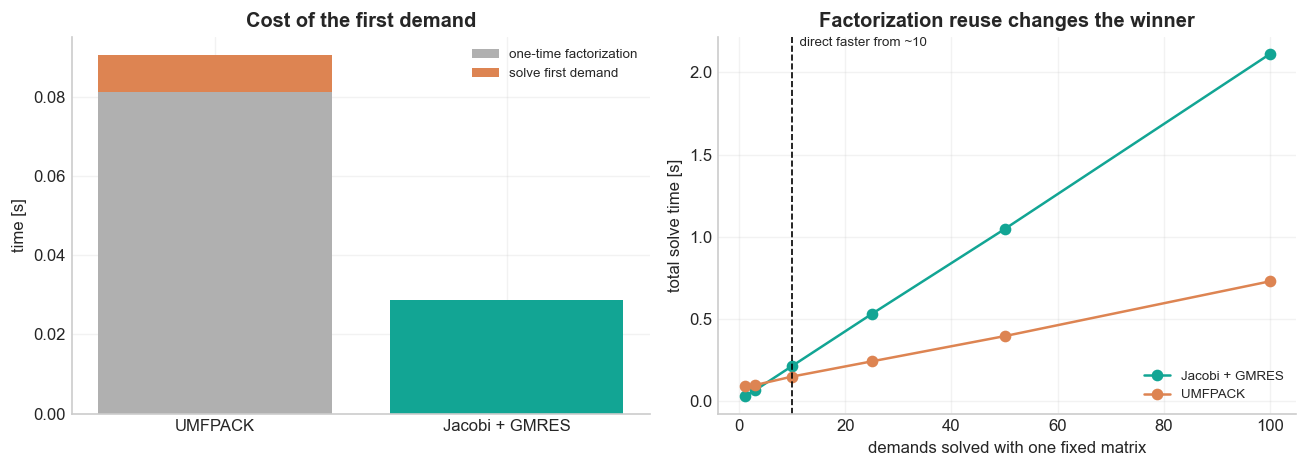

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

first_demand = rhs[
    (rhs.rhs_count == 1) & rhs.solver.isin(["umfpack", "jacobi-gmres"])
].set_index("solver")
bar_solvers = [
    solver for solver in ["umfpack", "jacobi-gmres"] if solver in first_demand.index
]
x = np.arange(len(bar_solvers))
setup_time = [
    first_demand.loc[solver, "factorization_seconds"] for solver in bar_solvers
]
solve_time = [first_demand.loc[solver, "rhs_solve_seconds"] for solver in bar_solvers]
axes[0].bar(x, setup_time, label="one-time factorization", color="#B0B0B0")
axes[0].bar(
    x,
    solve_time,
    bottom=setup_time,
    label="solve first demand",
    color=[colors[solver] for solver in bar_solvers],
)
axes[0].set_xticks(x, [solver_names[solver] for solver in bar_solvers])
axes[0].set_ylabel("time [s]")
axes[0].set_title("Cost of the first demand")
axes[0].legend(frameon=False, fontsize=8)

for solver, subset in rhs.groupby("solver"):
    axes[1].plot(
        subset["rhs_count"],
        subset["solve_seconds"],
        "o-",
        label=solver_names[solver],
        color=colors[solver],
    )

comparison = rhs[rhs.solver.isin(["umfpack", "jacobi-gmres"])].pivot(
    index="rhs_count", columns="solver", values="solve_seconds"
)
if {"umfpack", "jacobi-gmres"}.issubset(comparison.columns):
    direct_wins = comparison.index[comparison["umfpack"] < comparison["jacobi-gmres"]]
    if len(direct_wins):
        crossover = direct_wins.min()
        axes[1].axvline(crossover, color="black", linestyle="--", linewidth=1)
        axes[1].text(
            crossover,
            axes[1].get_ylim()[1],
            f"  direct faster from ~{crossover:,}",
            va="top",
            fontsize=8,
        )

axes[1].set_xlabel("demands solved with one fixed matrix")
axes[1].set_ylabel("total solve time [s]")
axes[1].set_title("Factorization reuse changes the winner")
axes[1].legend(frameon=False, fontsize=8)
for axis in axes:
    axis.grid(alpha=0.25)
fig.tight_layout()
plt.show()


# 3 · Changing matrix, repeated solves

This is a 500-iteration synthetic **Monte Carlo** analogue: the technosphere matrix changes slightly at every sample.  
UMFPACK must refactorize each matrix. Jacobi + GMRES is shown both with a warm start from the previous solution and without one, matching the role of `use_guess` in `bw2calc`.


In [13]:
%%time

demand = np.zeros(10_000)
demand[0] = 1.0
records = []
coupling_rng = np.random.default_rng(SEED)
sample_couplings = np.clip(0.8 + coupling_rng.normal(0, 0.015, 500), 0.7, 0.9)
solver_cases = [
    *((solver, solver, False) for solver in DIRECT_SOLVERS),
    ("jacobi-gmres", "jacobi-gmres", True),
    ("jacobi-gmres-no-guess", "jacobi-gmres", False),
]

for label, solver, reuse_guess in solver_cases:
    previous_solution = None
    for sample in range(500):
        matrix = banded_matrix(
            10_000,
            4,
            SEED,
            4.0,
            coupling=float(sample_couplings[sample]),
        )
        solve_started = perf_counter()
        solution, info, count = solve(
            matrix,
            demand,
            solver,
            RTOL,
            50,
            300,
            x0=previous_solution if reuse_guess else None,
        )
        elapsed = perf_counter() - solve_started
        residual = float(
            np.linalg.norm(matrix @ solution - demand) / np.linalg.norm(demand)
        )
        assert info in (None, 0) and residual <= RTOL * 1.01
        if reuse_guess:
            previous_solution = solution
        records.append(
            {
                "solver": label,
                "sample": sample,
                "solve_seconds": elapsed,
                "iterations": count,
                "relative_residual": residual,
                "info": info,
            }
        )
changing = pd.DataFrame(records)
per_sample = changing.copy()
per_sample["cumulative_seconds"] = per_sample.groupby("solver")[
    "solve_seconds"
].cumsum()
per_sample["monte_carlo_iteration"] = per_sample["sample"].astype(int) + 1
mc_summary = (
    per_sample.groupby("solver")
    .agg(
        total_seconds=("solve_seconds", "sum"),
        median_iterations=("iterations", "median"),
        max_relative_residual=("relative_residual", "max"),
        failed_solves=("info", lambda values: int(values.dropna().ne(0).sum())),
    )
    .reset_index()
)
assert mc_summary["failed_solves"].eq(0).all()
assert mc_summary["max_relative_residual"].le(RTOL * 1.01).all()
display(
    mc_summary.style.format(
        {
            "total_seconds": "{:.2f}",
            "median_iterations": "{:.0f}",
            "max_relative_residual": "{:.2e}",
        }
    ).hide(axis="index")
)


solver,total_seconds,median_iterations,max_relative_residual,failed_solves
jacobi-gmres,0.70,13,9.96e-05,0
jacobi-gmres-no-guess,1.00,18,9.90e-05,0
umfpack,2.00,0,3.15e-14,0


CPU times: user 6.09 s, sys: 287 ms, total: 6.37 s
Wall time: 6.38 s


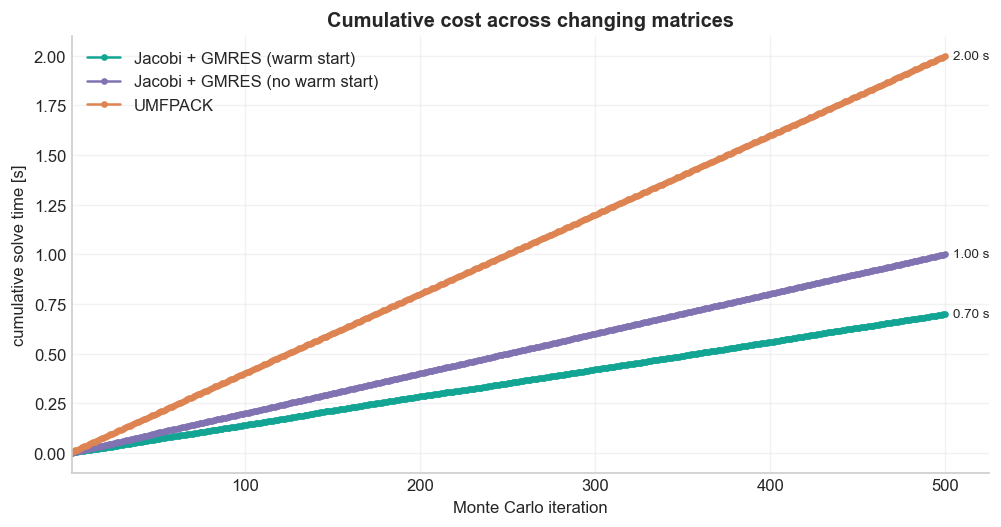

In [14]:
fig, axis = plt.subplots(figsize=(8.5, 4.5))
for solver, subset in per_sample.groupby("solver"):
    label = (
        "Jacobi + GMRES (warm start)"
        if solver == "jacobi-gmres"
        else solver_names[solver]
    )
    axis.plot(
        subset["monte_carlo_iteration"],
        subset["cumulative_seconds"],
        "o-",
        label=label,
        color=colors[solver],
        markersize=3,
    )
    final = subset.iloc[-1]
    axis.annotate(
        f"{final['cumulative_seconds']:.2f} s",
        (final["monte_carlo_iteration"], final["cumulative_seconds"]),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=8,
    )
axis.set_xlabel("Monte Carlo iteration")
axis.set_ylabel("cumulative solve time [s]")
axis.set_title("Cumulative cost across changing matrices")
axis.set_xlim(1, per_sample["monte_carlo_iteration"].max() * 1.05)
axis.grid(alpha=0.25)
axis.legend(frameon=False)
fig.tight_layout()
plt.show()


# 4 · JacobiGMRESLCA in bw2calc

In Brightway, `bw2calc.JacobiGMRESLCA` changes the technosphere solve while leaving biosphere and
characterization processing unchanged. Main arguments are `demand`, `method`, `rtol`, `use_guess`,
`restart`, and `maxiter`.

For repeated solves, `use_guess=True` starts from the previous supply array; `False` starts each
solve without that warm start.

```python
from bw2calc import JacobiGMRESLCA
lca = JacobiGMRESLCA({activity.id: 1.0}, method, rtol=1e-4, use_guess=True)
lca.lci()
lca.lcia()
print(lca.score)
```

Check convergence, residual, and agreement before interpreting an iterative score.


# When to use **Jacobi + GMRES**

**Good fit when:**

- The system is **very large and sparse** and not **narrowly banded**.
- The matrix **changes repeatedly**.
- A direct factorization is close to the machine's **memory limit**.
- A **controlled tolerance** is acceptable.

**Choose UMFPACK or Pardiso when:**

- The matrix is small or moderate, or **narrowly banded**.
- Many demands reuse one fixed matrix.
- You need a direct answer and factorization fits comfortably in memory.

# How it ended

![UMFPACK vs. JacobiGMRED](assets/figure_2.png)